In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append("../utils")
sys.path.append("../training")
import matplotlib.pyplot as plt
import matplotlib
import os

from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from geometric_features import get_path_sig, get_path_sigs
import iisignature
from stage_dataset import StageDataset
from tqdm.auto import tqdm
from umap import UMAP

from scipy.spatial.distance import cdist
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from stats_utils import prfcm, disp_cm
import torch
tqdm.pandas()

# Ideas:
* Do different stages form coherent clusters via path sigs? (this should be fairly fruitful)
* Do different grades form coherent clusters via path sigs? (probably not but could be cool to show different shapes)
* Are there any other patterns, say for certain kinds of clusters, images look one way. (might be a rather involved analysis)

In [2]:
# hyperparameters
model_name = "convlstm_final-2026-07-13"
TIME_OFFSET = 5
PCA_DIM = 16
path_sig_depth = 2
GRADE_COLORS = {"A":(0,1,0), "B":(1,1,0), "C":(1,0,0)}

In [3]:
# load latents and metadata
metadata_df = pd.read_csv(os.path.join("latents",f"{model_name}.csv"))
latents = np.load(os.path.join("latents",f"{model_name}.npy"))

latents_df = pd.DataFrame(latents, columns=[f"z_{i}" for i in range(latents.shape[1])], index=metadata_df.index)
pca_cols = [f"pca_{i}" for i in range(PCA_DIM)]
pca = PCA(n_components=PCA_DIM)
pca_latents = pca.fit_transform(StandardScaler().fit_transform(latents))
print(pca.explained_variance_ratio_)
pca_latents_df = pd.DataFrame(pca_latents, columns=pca_cols, index=metadata_df.index)
df = pd.concat([metadata_df, latents_df, pca_latents_df], axis=1)
embryos = list(df[df["TE"] == "A"]["embryo_id"].unique())
np.random.shuffle(embryos)
embryos = embryos[:int(0.3 * len(embryos))]
embryos += list(df[df["TE"] == "C"]["embryo_id"].unique())
mask = df["embryo_id"].isin(embryos)
# only graded
df = df[mask]
# pick out some random embryo_ids so that we can look at smaller subsets
# embryo_ids = df["embryo_id"].unique()
# np.random.shuffle(embryo_ids)
# embryo_ids = embryo_ids[:int(len(embryo_ids) * 0.3)]
# df = df[df["embryo_id"].isin(embryo_ids)]

[0.34062112 0.101319   0.05344034 0.04670937 0.04072883 0.03338663
 0.02628849 0.023812   0.0224803  0.01908352 0.0179054  0.01504763
 0.01402296 0.01342308 0.01248933 0.01095414]


In [4]:
ps_cols = [f"path_sig_{i}" for i in range(len(iisignature.basis(iisignature.prepare(PCA_DIM+1, path_sig_depth))))]

def path_sig_agg(group):
    pca_traj = group[pca_cols].to_numpy()
    path_sig = get_path_sig(pca_traj, path_sig_depth, time_offsets=TIME_OFFSET)
    out_df = pd.DataFrame(path_sig[None, :], columns = ps_cols)
    out_df["phase"] = [group.name[1]] # the second key is 'phase'
    out_df["grade"] = [group.iloc[0]["TE"]]
    return out_df
path_sig_df = df.groupby(["embryo_id", "phase"]).progress_apply(path_sig_agg).reset_index(drop=True)



  0%|          | 0/668 [00:00<?, ?it/s]

/home/jenslundsgaard/ivf/.venv/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


/tmp/ipykernel_1208845/1487081269.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(visual_ps[:,0], visual_ps[:,1], visual_ps[:,2], c=visual_ps_colors, vmin=0, vmax=19)


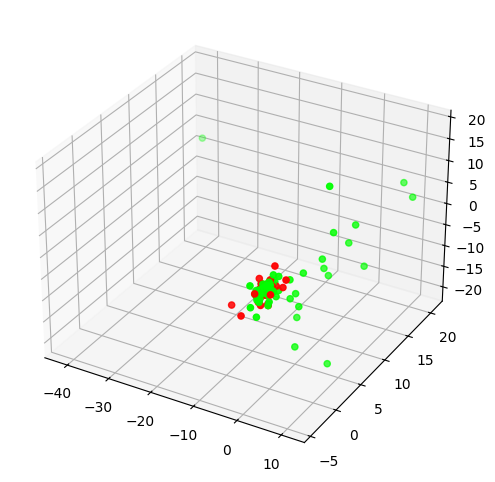

In [5]:
%matplotlib inline
GRADES = ["A","B", "C"]
GRADE_COLORS = {"A":"#00FF00", "B":"#FFFF00", "C":"#FF0000"}
path_sig_df["grade_indices"]  = [GRADES.index(p) for p in path_sig_df['grade'].to_list()]

p = ["t9+","tM", "tSB", "tB", "tEB"]
phase_path_sig_df = path_sig_df[path_sig_df['phase'].isin(p)]

normed_path_sigs = StandardScaler().fit_transform(phase_path_sig_df[ps_cols].to_numpy())
visual_ps = PCA(n_components=3).fit_transform(normed_path_sigs)
visual_ps_colors = [GRADE_COLORS[GRADES[g]] for g in phase_path_sig_df["grade_indices"].to_list()]
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], visual_ps[:,2], c=visual_ps_colors, vmin=0, vmax=19)
plt.show()
plt.close(fig)
plt.close()